In [ ]:
import numpy as np
matrix = np.ones((5,5))
matrix[1:4,1:4] = 0 # taking from row 1:4 as the row in this case and 1:4 as the column and assigning 0 to it
print(matrix)

#Task 2
np.random.seed(42)
random_data = np.random.randn(100, 3)
print(random_data)
normalized = (random_data - random_data.mean(axis=0)) / random_data.std(axis=0)
print (normalized) 

#Task 3
X = np.random.randn(50, 3)
true_theta = np.array([2.5, -1.2, 3.7])
y = X @ true_theta + np.random.randn(50) * 0.1

# Add bias term (
X_b = np.c_[np.ones((50, 1)), X]

# normal equation
theta_hat = np.linalg.inv(X_b.T @ X_b) @ X_b.T @ y

print("Estimated theta:", theta_hat)
print("True theta (with bias assumed 0):", true_theta)

[[1. 1. 1. 1. 1.]
 [1. 0. 0. 0. 1.]
 [1. 0. 0. 0. 1.]
 [1. 0. 0. 0. 1.]
 [1. 1. 1. 1. 1.]]


In [46]:
import pandas as pd
import numpy as np
np.random.seed(42)
n_students = 200
data = {
    'student_id': range(1000, 1000 + n_students),
    'major': np.random.choice(['CS', 'Math', 'Physics', 'Biology'], n_students),
    'year': np.random.choice([1, 2, 3, 4], n_students),
    'exam_score': np.random.normal(75, 10, n_students).clip(0, 100),
    'assignments_completed': np.random.randint(0, 11, n_students),
    'hours_studied': np.random.normal(15, 5, n_students).clip(1, 40)
}
df = pd.DataFrame(data)
df.loc[np.random.choice(n_students, 10), 'exam_score'] = np.nan
df.loc[np.random.choice(n_students, 5), 'hours_studied'] = np.nan
 
#Task 1 

print(df.info())
print(df.isnull().sum())
df['exam_score'] = df['exam_score'].fillna(
df.groupby('major')['exam_score'].transform('mean')
)
df['hours_studied'] = df['hours_studied'].fillna(
df.groupby('year')['hours_studied'].transform('median')
)

#Task 2
# caluculating the average exam score for each major
average_exam_score_by_major = df.groupby('major')['exam_score'].mean()
top_major = average_exam_score_by_major.idxmax()
top_score = average_exam_score_by_major.max()

# print the top major and its average score
print(f"Top Major: {top_major}")
print(f"Average Score: {top_score}")

#correlation between hours studied and exam score
print(f"Correlation between hours studied and exam score: {df['hours_studied'].corr(df['exam_score'])}")

#creating new column for performance category
Category = [df['exam_score'] > 90,
    (df['exam_score'] >= 80) & (df['exam_score'] <= 90),
    (df['exam_score'] >= 70) & (df['exam_score'] < 80),
    df['exam_score'] < 70
] 

#assigning performance category based on the conditions defined in Category list
grading_categories = ['Excellent', 'Good', 'Average', 'Needs Improvement']
df['performance'] = np.select(Category, grading_categories, default ='Unknown')


#Task 3
population = df.groupby(['major', 'year']).agg(
    student_count=('student_id', 'count'),
    avg_exam_score=('exam_score', 'mean'),
    avg_hours_studied=('hours_studied', 'mean')
)

population = df.groupby(['major', 'year']).agg(
    student_count=('student_id', 'count'),
    avg_exam_score=('exam_score', 'mean'),
    avg_hours_studied=('hours_studied', 'mean')
)
print(population)

#Pivot Table
pivot = df.pivot_table(
    values = 'exam_score',
    index = 'major',
    columns = 'year',
    aggfunc = 'mean'
)

print(pivot)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 6 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   student_id             200 non-null    int64  
 1   major                  200 non-null    object 
 2   year                   200 non-null    int64  
 3   exam_score             190 non-null    float64
 4   assignments_completed  200 non-null    int64  
 5   hours_studied          195 non-null    float64
dtypes: float64(2), int64(3), object(1)
memory usage: 9.5+ KB
None
student_id                0
major                     0
year                      0
exam_score               10
assignments_completed     0
hours_studied             5
dtype: int64
Top Major: CS
Average Score: 76.42518387979709
Correlation between hours studied and exam score: -0.055981383472924404
              student_count  avg_exam_score  avg_hours_studied
major   year                                      

KeyError: 'exam_score'

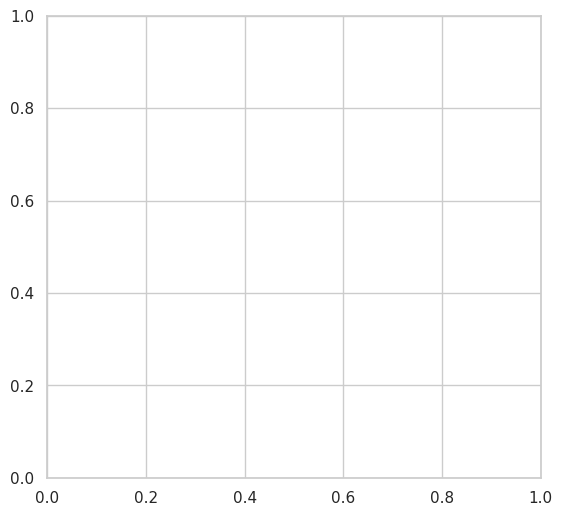

In [74]:
import matplotlib.pyplot as plt
import seaborn as sns

#Histogram of exam scores with KDE overlay
plt.figure(figsize=(14,6))
plt.subplot(1, 2, 1)
sns.histplot(df['exam_score'], kde=True, bins=20, color='red')
plt.title('Distribution of Exam Scores')
plt.xlabel('Exam Score')
plt.ylabel('Frequency')

#Box plot of exam scores by major
plt.subplot(1, 2, 2)
sns.boxplot(x='major', y='exam_score', data=df)

plt.title('Exam Scores by Major')
plt.xlabel('Major')
plt.ylabel('Exam Score')
plt.subplot(1, 2, 2)
sns.boxplot(x='major', y='exam_score', data=df)

plt.title('Exam Scores by Major')
plt.xlabel('Major')
plt.ylabel('Exam Score')

plt.figure(figsize=(10, 6))

sns.set(style="whitegrid")

# Scatter plot with regression line + color by major
sns.lmplot(
    data=df,
    x='hours_studied',
    y='exam_score',
    hue='major',
    height=6,
    aspect=1.5,
    scatter_kws={'alpha': 0.7}
)

plt.title('Relationship between Hours Studied and Exam Score')
plt.xlabel('Hours Studied')
plt.ylabel('Exam Score')

plt.show()

sns.set(style="whitegrid")

fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# 1. Bar chart: Avg exam score by major

avg_major = df.groupby('major')['exam_score'].mean()

avg_major.plot(kind='bar', ax=axes[0, 0], color='green')
axes[0, 0].set_title('Average Exam Score by Major')
axes[0, 0].set_xlabel('Major')
axes[0, 0].set_ylabel('Average Exam Score')


# 2. Count plot: Students by year

sns.countplot(data=df, x='year', ax=axes[0, 1], palette='Set2')

axes[0, 1].set_title('Number of Students by Year')
axes[0, 1].set_xlabel('Year')
axes[0, 1].set_ylabel('Count')

#  Heatmap: Correlation matrix
correlation = df[['exam_score', 'hours_studied', 'assignments_completed']].corr()

sns.heatmap(correlation, annot=True, cmap='coolwarm', ax=axes[1, 0])

axes[1, 0].set_title('Correlation Matrix')

# 4. Violin plot: Exam score by performance
sns.violinplot(
    data=df,
    x='performance',
    y='exam_score',
    ax=axes[1, 1],
    palette='Pastel1'
)
# Final layout adjustments
plt.tight_layout()
plt.show()




/tmp/ipykernel_3939/530424486.py:42: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_summary = df.groupby('age_group').agg(


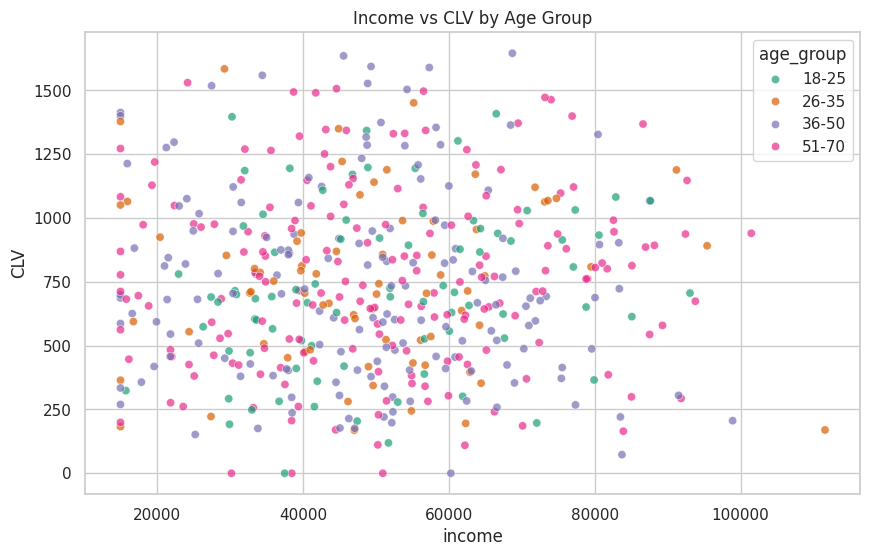

/tmp/ipykernel_3939/530424486.py:83: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  avg_clv = df.groupby('age_group')['CLV'].mean().sort_values()
/tmp/ipykernel_3939/530424486.py:87: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=avg_clv.index, y=avg_clv.values, palette='viridis')


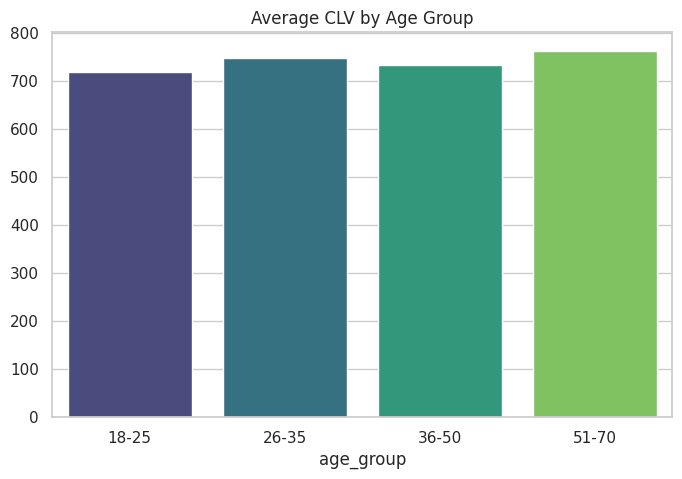

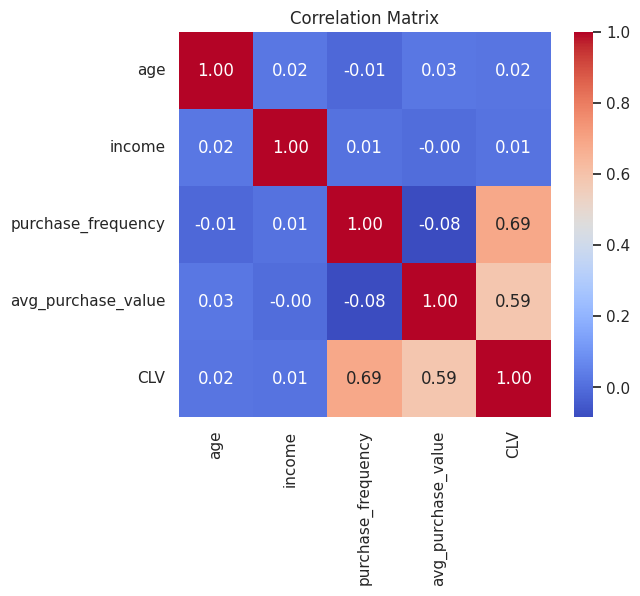

In [76]:
import seaborn as sns
import matplotlib.pyplot as plt




np.random.seed(42)
n_customers = 500

# Generate customer data
ages = np.random.randint(18, 70, n_customers)
income = np.random.normal(50000, 20000, n_customers).clip(15000, 150000)
purchase_freq = np.random.poisson(5, n_customers)
avg_purchase_value = np.random.normal(100, 30, n_customers).clip(10, 500)

# Create DataFrame
customers = pd.DataFrame({
    'age': ages,
    'income': income,
    'purchase_frequency': purchase_freq,
    'avg_purchase_value': avg_purchase_value
})


##capute CLV
df = customers.copy()
max_freq = df['purchase_frequency'].max()
df['churn_risk'] = 1 - (df['purchase_frequency'] / max_freq)
df['CLV'] = df['purchase_frequency'] * df['avg_purchase_value'] * (1 + df['churn_risk'])


###Age Group
df['age_group'] = pd.cut(
    df['age'],
    bins=[18, 25, 35, 50, 70],
    labels=['18-25', '26-35', '36-50', '51-70'],
    include_lowest=True
)


##Age summary
age_summary = df.groupby('age_group').agg(
    customer_count=('age', 'count'),
    avg_income=('income', 'mean'),
    avg_clv=('CLV', 'mean'),
    total_clv=('CLV', 'sum')
)

age_summary


###Top 10% customers by CLV
threshold = df['CLV'].quantile(0.90)

top_customers = df[df['CLV'] >= threshold]

top_customers




####


plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df,
    x='income',
    y='CLV',
    hue='age_group',
    palette='Dark2',
    alpha=0.7
)

plt.title('Income vs CLV by Age Group')
plt.show()


###Average CLV by  Age group


avg_clv = df.groupby('age_group')['CLV'].mean().sort_values()

plt.figure(figsize=(8,5))

sns.barplot(x=avg_clv.index, y=avg_clv.values, palette='viridis')

plt.title('Average CLV by Age Group')
plt.show()


######Correlation HeatMap
plt.figure(figsize=(6,5))

sns.heatmap(df[['age','income','purchase_frequency','avg_purchase_value','CLV']].corr(),
            annot=True, cmap='coolwarm', fmt='.2f')

plt.title('Correlation Matrix')
plt.show()

This analysis shows that purchase frequency and average purchase value poses a strong influence on customer lifetime value (CLV). Higher engagement level bears enough evidence that customers tend to generate significantly higher CLV.
Also, the age group analysis indicates that customers from the 26–50-year range turn to contribute higher to the CLV than any other year group, this means they are the most import segments of the customer base. When customers spend more there is a higher income showing a positive relationship with CLV.
The large share of the total CLV is contributed by the top 10% of customer emphasizing the need for targeted retention strategies.
